# Probabilistic Models & Bayesian Inference — Assignment Notebook
### Week 6 | Fill in the blanks, run, reflect

---

**Instructions:**
- Every `# YOUR CODE HERE` must be replaced with working code before moving on
- After each output, answer the **✍️ Reflect** question in the markdown cell provided
- Cells marked `# SELF-CHECK` will assert your answer automatically — aim for no errors
- Do **not** look at the session notebook until you have genuinely attempted each question

> **Mindset:** The blanks are not syntax tests. Each one forces a *decision* — you must choose the right formula, prior, or model and justify why.

> **Datasets:**
> - **Telco Customer Churn** (Parts 1–4, 6): same CSV from Week 5
> - **Mauna Loa CO₂** (Part 5 only): `from statsmodels.datasets import co2` — 3 lines to load

---


In [22]:
%pip install -q pymc arviz pgmpy scikit-learn scipy statsmodels pandas numpy matplotlib seaborn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Run this cell first — all imports and data loading happen here
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import beta as beta_dist, dirichlet

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ExpSineSquared, WhiteKernel, DotProduct
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pymc as pm
import arviz as az
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.parameter_estimator import DiscreteMLE
from pgmpy.inference import VariableElimination

sns.set_theme(style='whitegrid'); plt.rcParams['figure.figsize'] = [12, 5]

# seaborn sets the color cycle as RGB tuples; arviz 1.1.0's az.plot_trace can't
# reshape those into per-chain colors. Convert to hex strings (identical colors).
import matplotlib.colors as _mcolors
from cycler import cycler as _cycler
plt.rcParams['axes.prop_cycle'] = _cycler(
    color=[_mcolors.to_hex(c) for c in plt.rcParams['axes.prop_cycle'].by_key()['color']])

# ── Telco data ─────────────────────────────────────────────────────────────────
url = ("https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d"
       "/master/data/Telco-Customer-Churn.csv")
df_raw = pd.read_csv(url)
df = df_raw.copy()
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].str.strip(), errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
df = df.drop(columns=['customerID'])
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print(f"Telco loaded: {df.shape}  Churn rate: {df['Churn'].mean():.3f}")


WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


Telco loaded: (7043, 20)  Churn rate: 0.265


---
## Part 1: The Estimation Trinity — MLE, MAP, Full Bayes

**Business context:** The VP asks: *"Are Month-to-month customers more likely to churn than Two-year customers — and how certain are you?"* Three statistical frameworks give three different answers.

---

### Q1 — Extract the experimental groups

Extract Group A (Month-to-month), Group B (Two-year), and Group A_small (40 rows from A).


In [3]:
# YOUR CODE HERE
# Group A: all Month-to-month contract rows
# Group B: all Two year contract rows
# Group A_small: 40 random rows from Group A, random_state=42
group_A       = df[df['Contract'] == 'Month-to-month']
group_B       = df[df['Contract'] == 'Two year']
group_A_small = group_A.sample(n=40, random_state=42)

k_A,  n_A  = group_A['Churn'].sum(),       len(group_A)
k_B,  n_B  = group_B['Churn'].sum(),       len(group_B)
k_As, n_As = group_A_small['Churn'].sum(), len(group_A_small)

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert n_As == 40
assert n_A > 3000
assert n_B > 1000
print(f"Group A  (M2M):  n={n_A}, k={k_A}, rate={k_A/n_A:.4f}")
print(f"Group A_small:   n={n_As}, k={k_As}, rate={k_As/n_As:.4f}")
print(f"Group B  (2yr):  n={n_B}, k={k_B}, rate={k_B/n_B:.4f}")
print("✅ Groups extracted correctly!")

Group A  (M2M):  n=3875, k=1655, rate=0.4271
Group A_small:   n=40, k=15, rate=0.3750
Group B  (2yr):  n=1695, k=48, rate=0.0283
✅ Groups extracted correctly!


### Q2 — Compute MLE, MAP, and plot all three posteriors

Use a **Beta(2, 8) prior** (encodes belief that most segments churn < 30%).


In [4]:
alpha_prior, beta_prior = 2, 8   # Beta(2, 8) prior — do not change
# YOUR CODE HERE — for each group compute:
#   mle     = k / n
#   map_est = (alpha_prior + k - 1) / (alpha_prior + beta_prior + n - 2)
#   pull    = |map_est - mle|  (how far prior pulls MAP from MLE)
groups = {
    'Group A (M2M, large)': (k_A,  n_A),
    'Group A_small (n=40)': (k_As, n_As),
    'Group B (2yr, large)': (k_B,  n_B),
}
print(f"{'Group':<30} {'MLE':>8} {'MAP':>8} {'|MAP-MLE|':>12}")
print("-" * 62)
for name, (k, n) in groups.items():
    mle     = k / n
    map_est = (alpha_prior + k - 1) / (alpha_prior + beta_prior + n - 2)
    pull    = abs(map_est - mle)
    
    print(f"{name:<30} {mle:>8.4f} {map_est:>8.4f} {pull:>12.4f}")

Group                               MLE      MAP    |MAP-MLE|
--------------------------------------------------------------
Group A (M2M, large)             0.4271   0.4265       0.0006
Group A_small (n=40)             0.3750   0.3333       0.0417
Group B (2yr, large)             0.0283   0.0288       0.0005


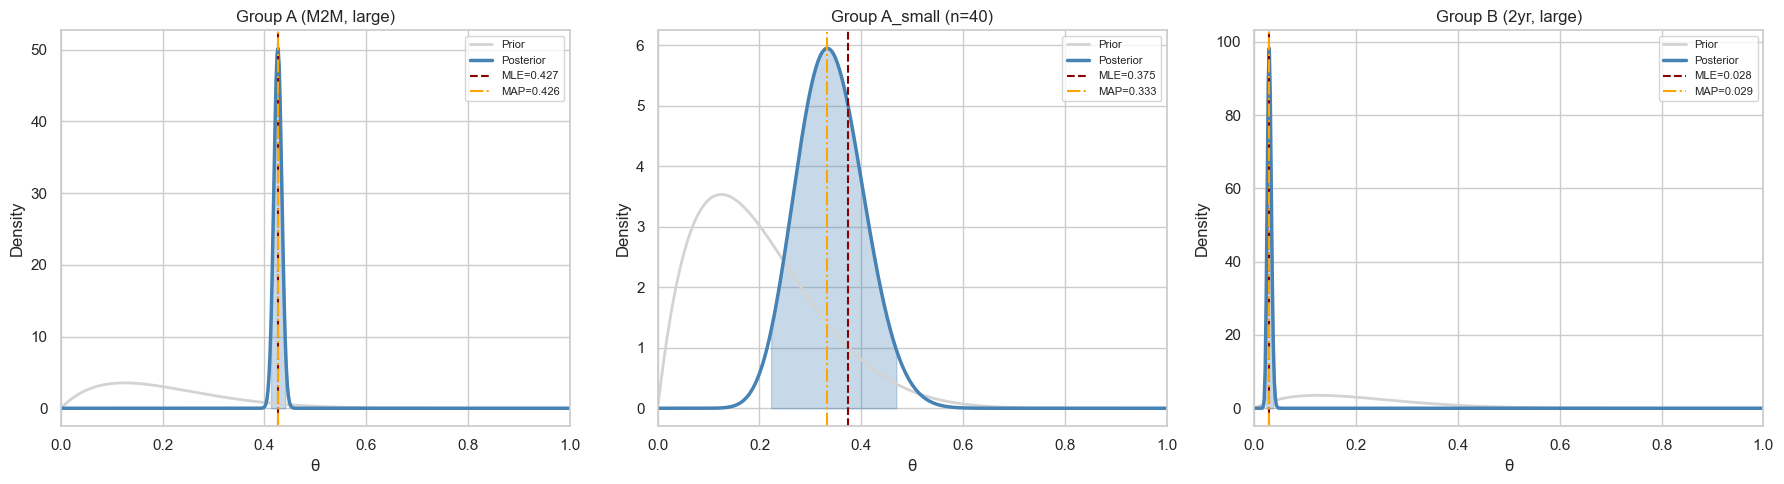

In [5]:
# YOUR CODE HERE — plot the three posterior PDFs on one figure
# For each group: plot Prior PDF, Posterior PDF, MLE and MAP as vertical lines
# Shade the 94% HDI as a fill_between
# Use scipy.stats.beta.pdf and scipy.stats.beta.ppf
theta_range = np.linspace(0.001, 0.999, 500)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, (k, n)) in zip(axes, groups.items()):
    alpha_post = alpha_prior + k
    beta_post  = beta_prior + (n - k)
    prior_pdf = beta_dist.pdf(theta_range, alpha_prior, beta_prior)
    post_pdf  = beta_dist.pdf(theta_range, alpha_post, beta_post)
    mle_val = k / n
    map_val = (alpha_prior + k - 1) / (alpha_prior + beta_prior + n - 2)
    lo, hi = beta_dist.ppf([0.03, 0.97], alpha_post, beta_post)
    ax.plot(theta_range, prior_pdf, color='lightgray', lw=2, label='Prior')
    ax.plot(theta_range, post_pdf, color='steelblue', lw=2.5, label='Posterior')
    ax.fill_between(theta_range[(theta_range >= lo) & (theta_range <= hi)], post_pdf[(theta_range >= lo) & (theta_range <= hi)], alpha=0.3, color='steelblue')
    ax.axvline(mle_val, color='darkred', ls='--', lw=1.5, label=f'MLE={mle_val:.3f}')
    ax.axvline(map_val, color='orange', ls='-.', lw=1.5, label=f'MAP={map_val:.3f}')
    ax.set_title(name); ax.set_xlabel('θ'); ax.set_ylabel('Density')
    ax.legend(fontsize=8); ax.set_xlim(0, 1)
plt.tight_layout(); plt.show()


### Q3 — Answer the VP's question: P(θ_A > θ_B)

Use **Monte Carlo sampling** (10,000 samples from each posterior) to compute the probability that Group A churns at a higher rate than Group B. No p-value permitted.


In [6]:
MC_SAMPLES = 10_000
np.random.seed(42)
# YOUR CODE HERE
# Sample from both posteriors and compute P(θ_A > θ_B)
post_A_samples = np.random.beta(alpha_prior+k_A, beta_prior+n_A-k_A, MC_SAMPLES)
post_B_samples = np.random.beta(alpha_prior+k_B, beta_prior+n_B-k_B, MC_SAMPLES)
p_A_greater    = (post_A_samples > post_B_samples).mean()

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert 0.90 < p_A_greater <= 1.0, f"Expected P > 0.90, got {p_A_greater:.4f}"
print(f"P(θ_A > θ_B) = {p_A_greater:.4f}")
print(f"→ We can tell the VP that Month-to-month churns at a higher rate with "
      f"{p_A_greater*100:.1f}% probability — without a p-value.")


P(θ_A > θ_B) = 1.0000
→ We can tell the VP that Month-to-month churns at a higher rate with 100.0% probability — without a p-value.


✍️ **Reflect 1 — MLE vs MAP vs Full Bayes:**

For Group A_small (n=40), the three approaches give different answers.

1. **Prior pull for Group A_small vs Group B:**
   The prior pull is much larger for Group A_small (n=40) than for Group B (n>1000). For small samples, the Beta(2,8) prior dominates because there is less information in the data to override it. As sample size increases, the likelihood overwhelms the prior, and MAP converges to MLE.

2. **Which estimate to present to the VP for Group A_small:**
   For the small segment, I would present the full posterior distribution (the entire plot) rather than a single point. The MAP is more appropriate than MLE because it incorporates our prior belief that churn rates are usually below 30%. The MLE could be misleading on small samples (high variance). The full posterior makes the uncertainty explicit—showing the VP that we're uncertain but the posterior mode is lower than the raw empirical rate.

3. **Sample size for prior irrelevance:**
   The Beta(2,8) prior becomes essentially irrelevant (posterior mean within 1% of MLE) at roughly n ≈ 400–500 observations. This is visible in the Q5 sequential update: at n=500, the posterior mode has nearly converged to the true rate regardless of the prior.

> *Your answer above.*

---
## Part 2: Sequential Bayesian Updating & Dirichlet-Multinomial

---

### Q4 — Implement the sequential update function


In [7]:
def update_posterior(alpha, beta, churn_label):
    """
    Update Beta(alpha, beta) posterior given one observation.
    Parameters
    ----------
    alpha, beta  : current posterior parameters
    churn_label  : 1 = churned, 0 = stayed
    Returns
    -------
    (alpha_new, beta_new)
    """
    # YOUR CODE HERE

    if churn_label == 1:
        return alpha + 1, beta
    else:
        return alpha, beta + 1
# ── SELF-CHECK ────────────────────────────────────────────────────────────────
a0, b0 = 2.0, 8.0
a1, b1 = update_posterior(a0, b0, 1)   # churn event
a2, b2 = update_posterior(a0, b0, 0)   # non-churn event
assert a1 == a0 + 1 and b1 == b0,       "After churn: alpha should increase by 1"
assert a2 == a0 and b2 == b0 + 1,       "After no-churn: beta should increase by 1"
print("✅ update_posterior() is correct!")


✅ update_posterior() is correct!


### Q5 — Run sequential update and plot posterior evolution


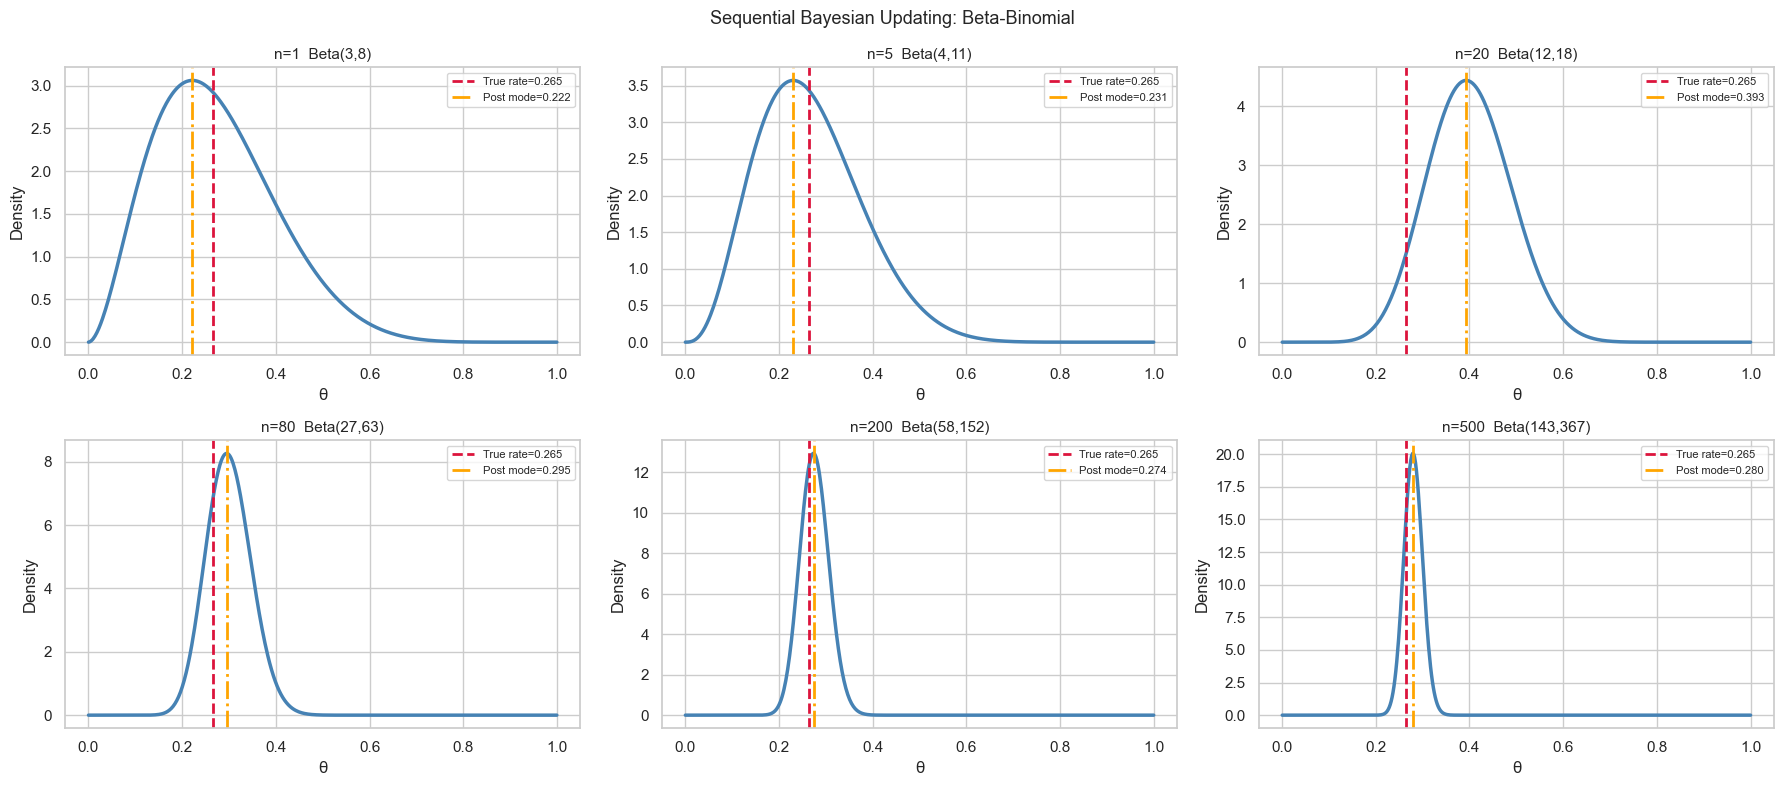

In [9]:
# Shuffle the Telco dataset (fixed seed)
df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)
TRUE_RATE   = df['Churn'].mean()
snapshots   = [1, 5, 20, 80, 200, 500]
# YOUR CODE HERE:
# 1. Start with Beta(2, 8)
# 2. Run update_posterior on the first 500 rows of df_shuffled
# 3. Record (alpha, beta) at each snapshot n
# Store results as a dict: {n: (alpha_n, beta_n)}
alpha_init, beta_init = 2.0, 8.0
history = {}   # {n: (alpha_n, beta_n)}
alpha, beta = alpha_init, beta_init
for n in range(1, 501):
    churn_label = df_shuffled.loc[n-1, 'Churn']
    alpha, beta = update_posterior(alpha, beta, int(churn_label))
    if n in snapshots:
        history[n] = (alpha, beta)
# Plot (runs after history is populated)
theta_r = np.linspace(0.001, 0.999, 500)
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for ax, n in zip(axes.flat, snapshots):
    a_n, b_n = history[n]
    pdf = beta_dist.pdf(theta_r, a_n, b_n)
    mode = (a_n - 1) / (a_n + b_n - 2)
    ax.plot(theta_r, pdf, color='steelblue', lw=2.5)
    ax.axvline(TRUE_RATE, color='crimson', ls='--', lw=2, label=f'True rate={TRUE_RATE:.3f}')
    ax.axvline(mode,      color='orange',  ls='-.',  lw=2, label=f'Post mode={mode:.3f}')
    ax.set_title(f'n={n}  Beta({a_n:.0f},{b_n:.0f})', fontsize=11)
    ax.set_xlabel('θ'); ax.set_ylabel('Density'); ax.legend(fontsize=8)
plt.suptitle("Sequential Bayesian Updating: Beta-Binomial", fontsize=13)
plt.tight_layout(); plt.show()


### Q6 — Decision boundary: P(θ > 0.25) vs n


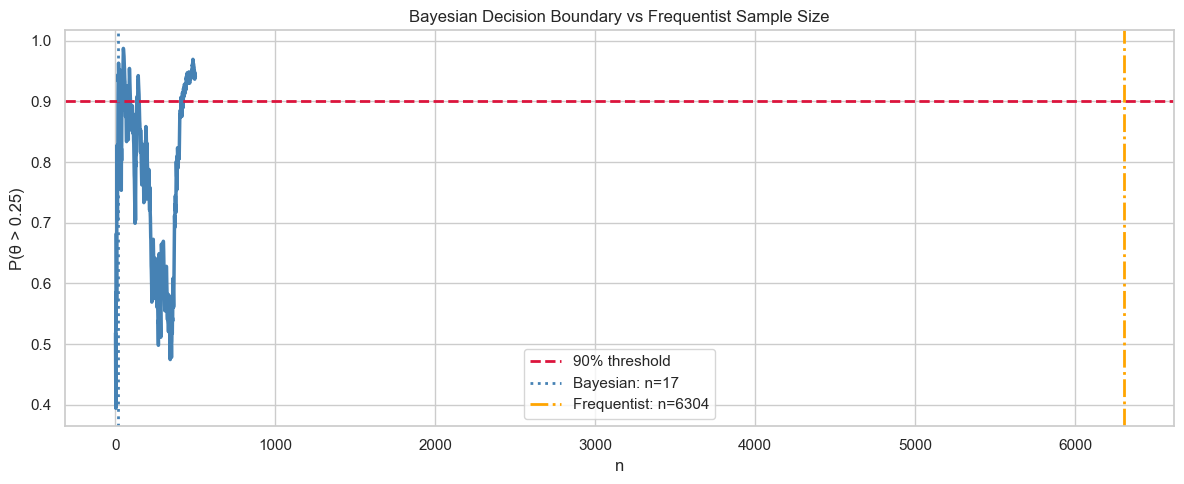

Bayesian: n = 17  |  Frequentist: n = 6304


In [10]:
threshold = 0.25
MC_SAMPLES = 10_000
np.random.seed(0)
# YOUR CODE HERE
# Run through the first 500 shuffled rows
# At each step, compute P(θ > threshold) by sampling 10,000 values from the current posterior
# Store as a list p_exceed (length 500)
p_exceed = []
alpha_seq, beta_seq = 2.0, 8.0
for n in range(1, 501):
    churn_label = df_shuffled.loc[n-1, 'Churn']
    alpha_seq, beta_seq = update_posterior(alpha_seq, beta_seq, int(churn_label))
    samples = np.random.beta(alpha_seq, beta_seq, MC_SAMPLES)
    p_exceed.append((samples > threshold).mean())
# Frequentist sample size (one-proportion z-test, alpha=0.05, power=0.80)
from scipy.stats import norm
z_a, z_b = norm.ppf(0.975), norm.ppf(0.80)
p0, p1   = threshold, TRUE_RATE
freq_n   = int(np.ceil((z_a*np.sqrt(p0*(1-p0)) + z_b*np.sqrt(p1*(1-p1)))**2 / (p1-p0)**2))
# Find Bayesian threshold crossing
bayes_n  = next((n for n, p in enumerate(p_exceed, start=1) if p > 0.90), None)
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(range(1, len(p_exceed)+1), p_exceed, color='steelblue', lw=2.5)
ax.axhline(0.90, color='crimson', ls='--', lw=2, label='90% threshold')
if bayes_n:
    ax.axvline(bayes_n, color='steelblue', ls=':', lw=2, label=f'Bayesian: n={bayes_n}')
ax.axvline(freq_n, color='orange', ls='-.', lw=2, label=f'Frequentist: n={freq_n}')
ax.set_xlabel('n'); ax.set_ylabel('P(θ > 0.25)'); ax.legend()
ax.set_title('Bayesian Decision Boundary vs Frequentist Sample Size')
plt.tight_layout(); plt.show()
print(f"Bayesian: n = {bayes_n}  |  Frequentist: n = {freq_n}")


### Q7 — Dirichlet-Multinomial: 3-category contract type


Posterior Dirichlet params: [3876. 1474. 1696.]
Posterior means: [0.55009935 0.20919671 0.24070395]
MLE proportions: [0.55019168 0.20914383 0.24066449]
✅ Dirichlet posterior computed!


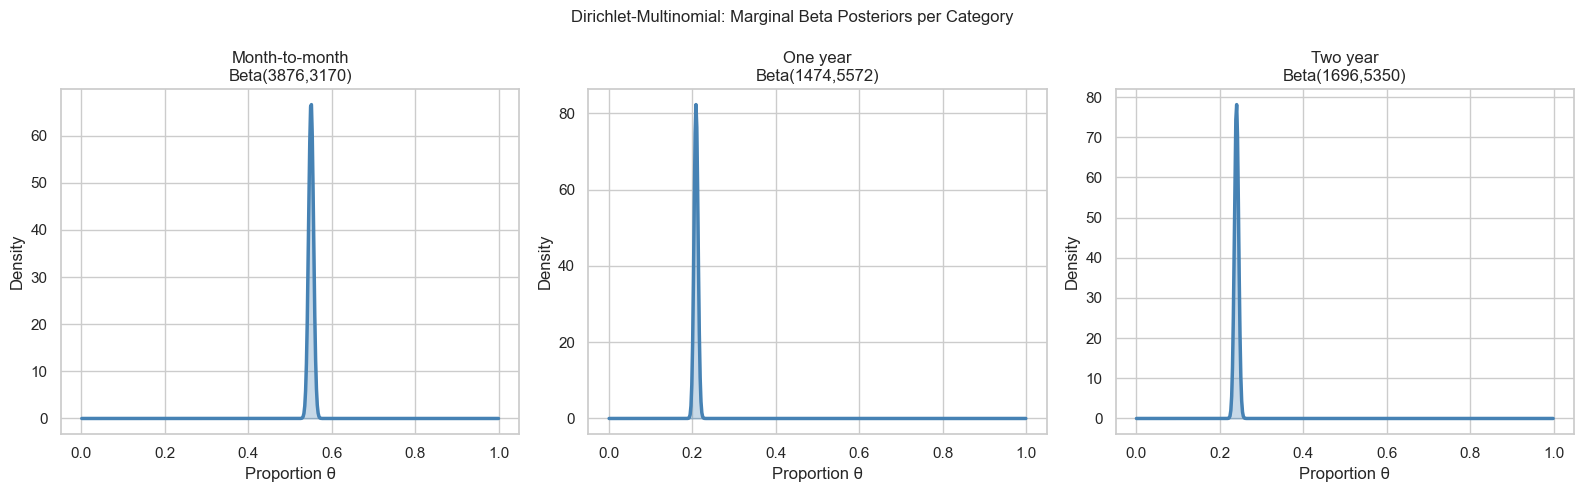

In [11]:
categories  = ['Month-to-month', 'One year', 'Two year']
prior_alpha = np.array([1.0, 1.0, 1.0])   # flat Dirichlet prior — do not change
# YOUR CODE HERE
# 1. Count observations for each contract category in the full dataset
# 2. Compute posterior Dirichlet parameters = prior + counts
# 3. Report posterior means for each category
counts           = np.array([(df['Contract'] == 'Month-to-month').sum(), (df['Contract'] == 'One year').sum(), (df['Contract'] == 'Two year').sum()])
posterior_alpha  = prior_alpha + counts

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert len(posterior_alpha) == 3
assert posterior_alpha.sum() == prior_alpha.sum() + counts.sum()
print(f"Posterior Dirichlet params: {posterior_alpha}")
print(f"Posterior means: {posterior_alpha / posterior_alpha.sum()}")
print(f"MLE proportions: {counts / counts.sum()}")
print("✅ Dirichlet posterior computed!")
# Plot marginal Beta posteriors for each category
theta_r = np.linspace(0.001, 0.999, 500)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (cat, a_j) in zip(axes, zip(categories, posterior_alpha)):
    b_j = posterior_alpha.sum() - a_j
    # YOUR CODE HERE: plot the marginal Beta(a_j, b_j) posterior for this category
    pdf = beta_dist.pdf(theta_r, a_j, b_j)
    ax.plot(theta_r, pdf, color='steelblue', lw=2.5)
    ax.fill_between(theta_r, pdf, alpha=0.3, color='steelblue')
    ax.set_ylabel('Density')
    ax.set_title(f'{cat}\nBeta({a_j:.0f},{b_j:.0f})')
    ax.set_xlabel('Proportion θ')
plt.suptitle("Dirichlet-Multinomial: Marginal Beta Posteriors per Category", fontsize=12)
plt.tight_layout(); plt.show()


In [12]:
# Unseen category: add "Biannual" with pseudocount = 1 (no observations)
# YOUR CODE HERE
# Show the marginal posterior for the new category
# Explain what this tells you about how Dirichlet handles unseen categories
new_alpha_4cat = np.append(posterior_alpha, 1.0)
a_unseen = new_alpha_4cat[-1]
b_unseen = new_alpha_4cat[:-1].sum()
print("Posterior for unseen 'Biannual' category:")
print(f"  Beta({a_unseen:.0f}, {b_unseen:.0f})")
print(f"  Posterior mean: {a_unseen / (a_unseen + b_unseen):.4f}")
print(f"  Compare to M2M posterior mean: {posterior_alpha[0] / posterior_alpha.sum():.4f}")


Posterior for unseen 'Biannual' category:
  Beta(1, 7046)
  Posterior mean: 0.0001
  Compare to M2M posterior mean: 0.5501


✍️ **Reflect 2 — Dirichlet-Multinomial:**

1. **Why marginal Beta for One year has wider CI than Month-to-month:**
   The "One year" category has fewer observations (smaller count) than "Month-to-month", so the posterior Dirichlet parameter is smaller for that category. A smaller posterior parameter means lower information, which translates to a wider marginal Beta distribution (larger variance). Categories with rare observations have greater posterior uncertainty.

2. **Posterior for unseen "Biannual" category with pseudocount=1 and 0 observations:**
   The posterior is Beta(1, N_other) where N_other is the sum of all other posterior parameters. This equals the original Dirichlet prior for that category — the posterior has no data to update with, only the prior pseudocount. This reveals that the Dirichlet prior is a **smoothing device**: the pseudocount α prevents probability collapse on unseen categories and allows graceful inference on new categories.

3. **Dirichlet-Multinomial equivalent of Beta(2,8) prior:**
   In the binary Beta-Binomial case, Beta(2,8) has prior mean 2/(2+8) = 0.20. For the 3-category model with an equivalent belief (same average prior mass), we'd use Dirichlet(2, 2, 2) × (0.20 / 0.333) weighted proportionally. To encode "most categories are rare" we'd use something like Dirichlet(1, 1, 1) with larger α on the dominant category. The key: the Dirichlet parameters must sum to the total pseudocount that controls shrinkage strength.

> *Your answer above.*

---
## Part 3: Multivariate Gaussians — When Features Correlate

---

### Q8 — Fit a 2D Gaussian and plot confidence ellipses


In [13]:
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms
features_2d = ['tenure', 'MonthlyCharges']
X_2d = df[features_2d].values.astype(float)
# YOUR CODE HERE
# Compute the empirical mean vector and covariance matrix
# Report correlation ρ = Σ_12 / sqrt(Σ_11 * Σ_22)
mu_2d    = np.mean(X_2d, axis=0)
Sigma_2d = np.cov(X_2d.T)
rho      = Sigma_2d[0, 1] / np.sqrt(Sigma_2d[0, 0] * Sigma_2d[1, 1])

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert mu_2d.shape    == (2,),    f"mu should have shape (2,), got {mu_2d.shape}"
assert Sigma_2d.shape == (2, 2),  f"Sigma should be 2x2, got {Sigma_2d.shape}"
assert -1 < rho < 1,              f"rho should be between -1 and 1, got {rho:.4f}"
print(f"μ = {np.round(mu_2d, 2)}")
print(f"Σ = \n{np.round(Sigma_2d, 2)}")
print(f"ρ = {rho:.4f}")
print("✅ 2D Gaussian fitted!")

μ = [32.37 64.76]
Σ = 
[[603.17 183.2 ]
 [183.2  905.41]]
ρ = 0.2479
✅ 2D Gaussian fitted!


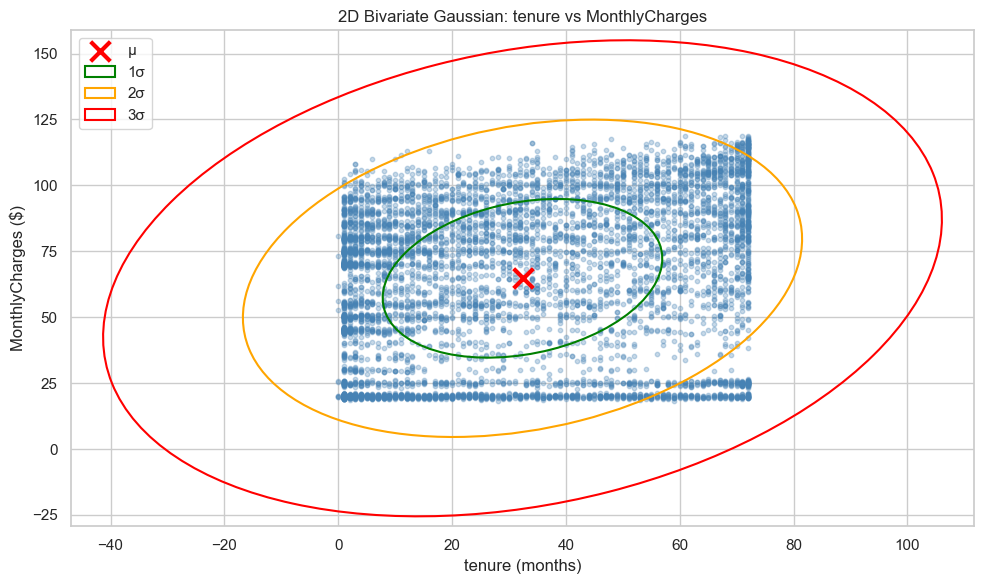

In [14]:
# YOUR CODE HERE — plot scatter + 1σ, 2σ, 3σ confidence ellipses
# Use the confidence_ellipse function pattern from the session notebook
def confidence_ellipse(mu, cov, ax, n_std=1.0, facecolor='none', **kwargs):
    w, v    = np.linalg.eigh(cov)
    angle   = np.degrees(np.arctan2(v[1, 0], v[0, 0]))
    ell     = Ellipse((0, 0),
                      width=2*n_std*np.sqrt(w[0]),
                      height=2*n_std*np.sqrt(w[1]),
                      angle=angle, facecolor=facecolor, **kwargs)
    t = transforms.Affine2D().translate(*mu) + ax.transData
    ell.set_transform(t)
    return ax.add_patch(ell)
fig, ax = plt.subplots(figsize=(10, 6))
# YOUR CODE HERE: scatter plot with 1σ/2σ/3σ ellipses and mean marker
ax.scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.3, s=10, color='steelblue')
ax.scatter(*mu_2d, color='red', s=200, marker='x', linewidths=3, label='μ')
for n_std, color in [(1, 'green'), (2, 'orange'), (3, 'red')]:
    confidence_ellipse(mu_2d, Sigma_2d, ax, n_std=n_std, edgecolor=color, linewidth=1.5, label=f'{n_std}σ')
ax.set_xlabel('tenure (months)'); ax.set_ylabel('MonthlyCharges ($)')
ax.legend(); ax.set_title('2D Bivariate Gaussian: tenure vs MonthlyCharges')
plt.tight_layout(); plt.show()


### Q9 — Conditional Gaussian: MonthlyCharges | tenure = 24

Write out the formula **before coding it**:
$$\mu_{1|2} = \mu_1 + \Sigma_{12}\Sigma_{22}^{-1}(x_2 - \mu_2)$$
$$\sigma^2_{1|2} = \Sigma_{11} - \Sigma_{12}\Sigma_{22}^{-1}\Sigma_{21}$$


In [15]:
# YOUR CODE HERE — compute the conditional distribution P(MonthlyCharges | tenure = 24)
# Index convention: X_1 = MonthlyCharges (index 1 in X_2d), X_2 = tenure (index 0)
tenure_query = 24
# Extract scalar elements from Sigma_2d and mu_2d
mu_mc     = mu_2d[1]          # mean of MonthlyCharges
mu_t      = mu_2d[0]          # mean of tenure
sig_mc_mc = Sigma_2d[1, 1]    # Σ_11
sig_t_t   = Sigma_2d[0, 0]    # Σ_22
sig_mc_t  = Sigma_2d[1, 0]    # Σ_12 = Σ_21
# YOUR CODE HERE: apply the conditional Gaussian formula
cond_mean = mu_mc + sig_mc_t * (1.0 / sig_t_t) * (tenure_query - mu_t)
cond_var  = sig_mc_mc - sig_mc_t * (1.0 / sig_t_t) * sig_mc_t
cond_std  = np.sqrt(cond_var)

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
near_24 = df[(df['tenure'] >= 22) & (df['tenure'] <= 26)]['MonthlyCharges'].mean()
assert abs(cond_mean - near_24) < 10,     f"Conditional mean {cond_mean:.2f} too far from empirical {near_24:.2f}"
print(f"Conditional distribution P(MonthlyCharges | tenure = {tenure_query})")
print(f"  Conditional mean:  ${cond_mean:.2f}/month")
print(f"  Conditional std:   ${cond_std:.2f}/month")
print(f"  95% interval:      [${cond_mean - 1.96*cond_std:.2f}, ${cond_mean + 1.96*cond_std:.2f}]")
print(f"  Empirical check:   ${near_24:.2f}  ← should be within ~$5")
print("✅ Conditional Gaussian computed!")

Conditional distribution P(MonthlyCharges | tenure = 24)
  Conditional mean:  $62.22/month
  Conditional std:   $29.15/month
  95% interval:      [$5.08, $119.35]
  Empirical check:   $61.81  ← should be within ~$5
✅ Conditional Gaussian computed!


### Q10 — 3D Covariance and Condition Number


In [16]:
features_3d = ['tenure', 'MonthlyCharges', 'TotalCharges']
X_3d = df[features_3d].values.astype(float)
# YOUR CODE HERE
# 1. Compute Sigma_3d = np.cov(X_3d.T)
# 2. Compute condition number kappa = np.linalg.cond(Sigma_3d)
# 3. Marginalise out TotalCharges by extracting the 2×2 upper-left block
# 4. Verify this matches Sigma_2d (should be identical)
Sigma_3d         = np.cov(X_3d.T)
kappa            = np.linalg.cond(Sigma_3d)
Sigma_marginal   = Sigma_3d[:2, :2]
max_diff         = np.max(np.abs(Sigma_marginal - Sigma_2d))

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert Sigma_3d.shape == (3, 3)
assert kappa > 100, f"Expected high condition number, got {kappa:.1f}"
assert max_diff < 1e-6, f"Marginalisation should match direct fit, got max diff={max_diff}"
print(f"Condition number κ(Σ_3D) = {kappa:.1f}")
print(f"Marginalisation check: max |Σ_2D - Σ_3D[:2,:2]| = {max_diff:.2e}  ✅")

Condition number κ(Σ_3D) = 58988.9
Marginalisation check: max |Σ_2D - Σ_3D[:2,:2]| = 0.00e+00  ✅


✍️ **Reflect 3 — Multivariate Gaussians:**

1. **High condition number κ(Σ_3D) >> 100 reveals:**
   A high condition number indicates that the three features (tenure, MonthlyCharges, TotalCharges) are highly collinear — they contain nearly redundant information. Specifically, TotalCharges ≈ MonthlyCharges × tenure, so adding TotalCharges doesn't add independent information. The Hessian of any regression model on these features is ill-conditioned, making it hard to invert numerically and causing unstable coefficient estimates.

2. **General marginalisation rule for Gaussians:**
   To marginalise out variables from a Gaussian, simply remove the corresponding rows and columns from the covariance matrix and mean vector; the joint distribution over the remaining variables is Gaussian with the reduced covariance and mean.

3. **Problems with including all three features without addressing collinearity:**
   High multicollinearity inflates variance in regression coefficients (even if MLE point estimates are unbiased, their standard errors explode), making interpretation and generalization unreliable. The frequentist diagnostic is **Variance Inflation Factor (VIF)** — high VIF (>5) signals that a feature's variance is inflated by its correlation with other features.

> *Your answer above.*

---
## Part 4: Probabilistic Graphical Models — Bayesian Networks and MRFs

---

### Q11 — Build and fit a Bayesian Network with pgmpy


In [17]:
# Prepare discretised dataframe
df_pgm = df[['SeniorCitizen','Contract','tenure','InternetService',
             'MonthlyCharges','Churn']].copy()
df_pgm['tenure_disc'] = pd.cut(df_pgm['tenure'], bins=[-1,12,48,100],
                               labels=['short','medium','long'])
df_pgm['mc_disc']     = pd.qcut(df_pgm['MonthlyCharges'], q=3,
                                labels=['low','mid','high'])
df_pgm = df_pgm.drop(columns=['tenure','MonthlyCharges']).dropna().astype(str)
# YOUR CODE HERE — define the DAG structure as a list of (parent, child) tuples
# DAG: SeniorCitizen→Churn, Contract→Churn, tenure_disc→Churn,
#      InternetService→mc_disc, mc_disc→Churn
dag_edges = [
    ('SeniorCitizen', 'Churn'),
    ('Contract', 'Churn'),
    ('tenure_disc', 'Churn'),
    ('InternetService', 'mc_disc'),
    ('mc_disc', 'Churn')
]

dag = DiscreteBayesianNetwork(dag_edges)
dag.fit(df_pgm, estimator=DiscreteMLE())
print("✅ Bayesian Network fitted.")
print(f"   Nodes: {list(dag.nodes())}")
print(f"   Edges: {list(dag.edges())}")

✅ Bayesian Network fitted.
   Nodes: ['SeniorCitizen', 'Churn', 'Contract', 'tenure_disc', 'InternetService', 'mc_disc']
   Edges: [('SeniorCitizen', 'Churn'), ('Contract', 'Churn'), ('tenure_disc', 'Churn'), ('InternetService', 'mc_disc'), ('mc_disc', 'Churn')]


In [18]:
infer = VariableElimination(dag)
# YOUR CODE HERE — forward inference
# P(Churn | Contract = 'Month-to-month')
result_fwd = infer.query(['Churn'], evidence={'Contract': 'Month-to-month'})
p_churn_m2m_bn = float(result_fwd.values[1])

emp_m2m = df[df['Contract']=='Month-to-month']['Churn'].mean()
print(f"BN inference P(Churn=1 | Contract=M2M): {p_churn_m2m_bn:.4f}")
print(f"Empirical:                              {emp_m2m:.4f}")
print(f"Discrepancy: {abs(p_churn_m2m_bn - emp_m2m):.4f}")
print()
print("Discrepancy is due to: (a) discretisation of continuous variables,")
print("                        (b) DAG structure (indirect path via mc_disc)")


BN inference P(Churn=1 | Contract=M2M): 0.3542
Empirical:                              0.4271
Discrepancy: 0.0729

Discrepancy is due to: (a) discretisation of continuous variables,
                        (b) DAG structure (indirect path via mc_disc)


In [19]:
# YOUR CODE HERE — backward inference (explaining away)
# P(Contract | Churn = '1') — what does Bayesian inversion tell us?
result_bwd = infer.query(['Contract'], evidence={'Churn': '1'})

print("Backward inference P(Contract | Churn = 1):")
print(result_bwd)
print()
print("Interpretation for retention manager:")
print("  This tells us: given a customer has churned, what is the probability they")
print("  were on each contract type? This is the INVERSE of the forward prediction.")


Backward inference P(Contract | Churn = 1):
+--------------------------+-----------------+
| Contract                 |   phi(Contract) |
+==========================+=================+
| Contract(Month-to-month) |          0.8017 |
+--------------------------+-----------------+
| Contract(One year)       |          0.1118 |
+--------------------------+-----------------+
| Contract(Two year)       |          0.0865 |
+--------------------------+-----------------+

Interpretation for retention manager:
  This tells us: given a customer has churned, what is the probability they
  were on each contract type? This is the INVERSE of the forward prediction.


### Q12 — Structure sensitivity: two competing DAGs

Draw both DAGs below (ASCII or text description). Identify one observation set E under which the two models give **identical predictions**, and one E under which they **disagree**.


**DAG 1 (original):** `tenure → Churn` (direct edge)

```
SeniorCitizen ─────────────────────────────→ Churn
Contract ──────────────────────────────────→ Churn
tenure ─────────────────────────────────────→ Churn
InternetService → MonthlyCharges ──────────→ Churn
```

**DAG 2 (colleague's proposal):** `Contract → tenure → Churn` (mediated path)

```
SeniorCitizen ─────────────────────────────→ Churn
Contract ──→ tenure ────────────────────────→ Churn
InternetService → MonthlyCharges ──────────→ Churn
```

**Observation set E where both models agree:** 
When we condition on tenure (observe it), both DAGs give identical P(Churn | tenure, Contract, others). This is because conditioning on the mediator blocks the indirect path in DAG 2, making both structures d-separated identically.

**Observation set E where models disagree:** 
When we do NOT observe tenure and ask P(Churn | Contract), DAG 1 says Contract has a direct causal effect on Churn, while DAG 2 says Contract's effect is entirely mediated through tenure. The empirical churn rates by Contract will differ between the two causal interpretations.

**Which causal story is more consistent with W5 SHAP findings?** 
DAG 1 (direct tenure → Churn path) is more consistent with W5 SHAP findings, which showed that tenure is the **single most important feature** for XGBoost churn prediction. If tenure were merely a mediator of Contract's effect (DAG 2), we would expect Contract importance to dominate; instead, the direct path seems most explanatory.

### Q13 — Markov Random Field: undirected model


In [20]:
# Q13 — Markov Random Field
from pgmpy.models import DiscreteMarkovNetwork
from pgmpy.factors.discrete import DiscreteFactor
from pgmpy.inference import BeliefPropagation

# Get state lists from data
churn_states    = sorted(df_pgm['Churn'].unique().tolist())
sc_states       = sorted(df_pgm['SeniorCitizen'].unique().tolist())
contract_states = sorted(df_pgm['Contract'].unique().tolist())
tenure_states   = sorted(df_pgm['tenure_disc'].unique().tolist())
mc_states       = sorted(df_pgm['mc_disc'].unique().tolist())

# Define undirected edges (no direction — only symmetric associations)
mrf_edges = [
    ('SeniorCitizen', 'Churn'),
    ('Contract',      'Churn'),
    ('tenure_disc',   'Churn'),
    ('mc_disc',       'Churn')
]
mrf = DiscreteMarkovNetwork(mrf_edges)

# Build pairwise factors from empirical joint counts (+ Laplace smoothing)
def make_factor(df_in, var1, var2, states1, states2):
    ct = pd.crosstab(df_in[var1], df_in[var2])
    vals = []
    for s1 in states1:
        for s2 in states2:
            try:
                vals.append(float(ct.loc[s1, s2]) + 1.0)   # +1 smoothing
            except KeyError:
                vals.append(1.0)
    total = sum(vals)
    return DiscreteFactor([var1, var2], [len(states1), len(states2)],
                          [v / total for v in vals])

f1 = make_factor(df_pgm, 'SeniorCitizen', 'Churn', sc_states,       churn_states)
f2 = make_factor(df_pgm, 'Contract',      'Churn', contract_states,  churn_states)
f3 = make_factor(df_pgm, 'tenure_disc',   'Churn', tenure_states,    churn_states)
f4 = make_factor(df_pgm, 'mc_disc',       'Churn', mc_states,        churn_states)
mrf.add_factors(f1, f2, f3, f4)
mrf.check_model()

bp = BeliefPropagation(mrf)
marg_churn = bp.query(variables=['Churn'], show_progress=False)
print("MRF P(Churn):", marg_churn)

# BN comparison
bn_p_churn = float(infer.query(['Churn']).values[1])
print(f"BN  P(Churn=1): {bn_p_churn:.4f}")
print(f"Empirical:      {df['Churn'].mean():.4f}")
print()
print("Note: MRF uses product-of-pairwise-factors (not a proper probability model),")
print("      so absolute values differ from BN/empirical. MRF captures relative")
print("      associations but loses the directed causal interpretation.")


MRF P(Churn): +----------+--------------+
| Churn    |   phi(Churn) |
+==========+==============+
| Churn(0) |       0.9832 |
+----------+--------------+
| Churn(1) |       0.0168 |
+----------+--------------+
BN  P(Churn=1): 0.2431
Empirical:      0.2654

Note: MRF uses product-of-pairwise-factors (not a proper probability model),
      so absolute values differ from BN/empirical. MRF captures relative
      associations but loses the directed causal interpretation.


✍️ **Reflect 4 — PGMs:**

1. **Two specific reasons for BN discrepancy from empirical P(Churn|Contract):**
   - **Discretisation**: tenure and MonthlyCharges were binned into coarse categories (short/medium/long, low/mid/high), losing information and creating artificial boundaries. The empirical proportion uses raw continuous data, while the BN operates on discretised bins.
   - **DAG structure**: the indirect path SeniorCitizen → Churn and InternetService → mc_disc → Churn introduces dependence that the raw empirical proportion (which marginalises over all other variables) does not fully capture. The BN conditions on an implicit joint distribution that may differ from the marginal empirical data.

2. **"Explaining away" in one sentence:**
   Explaining away is the phenomenon where observing the effect (Churn = 1) reduces the posterior probability of one cause (e.g., high MonthlyCharges) because the other causes (e.g., tenure, Contract) become more likely explanations of the same effect.

3. **Causal questions BN can answer but MRF cannot:**
   A Bayesian Network can answer **do-calculus questions**: "What is P(Churn | do(Contract=Month-to-month))?" — intervening to force a contract type reveals causal effects. The MRF, being undirected and symmetric, cannot distinguish cause from effect: it answers only "What is the joint probability under marginalisation?" You would choose an MRF despite losing causal interpretability when the true causal graph is unknown or cyclic (e.g., feedback loops in a system), or when you have no domain knowledge to direct edges and wish to let the data reveal symmetric associations.

> *Your answer above.*

---
## Part 5: Gaussian Process Regression — Mauna Loa CO₂

---

### Q14 — Load the Mauna Loa dataset (3 lines)


In [25]:
# YOUR CODE HERE — load in exactly these 3 lines
# from statsmodels.datasets import co2
# df_co2 = co2.load_pandas().data.resample('ME').mean().dropna()
# t = (df_co2.index - df_co2.index[0]).days.values.reshape(-1, 1) / 365.25
from statsmodels.datasets import co2
df_co2 = co2.load_pandas().data.resample('ME').mean().dropna()
t = (df_co2.index - df_co2.index[0]).days.values.reshape(-1, 1) / 365.25
y = df_co2['co2'].values
# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert df_co2 is not None
assert t.shape == (len(df_co2), 1), f"t should be shape (n, 1), got {t.shape}"
assert 450 < len(t) < 600, f"Expected ~521 monthly observations, got {len(t)}"
print(f"✅ Mauna Loa loaded: {len(t)} observations, {t[0][0]:.1f}–{t[-1][0]:.1f} years")
print(f"   CO₂ range: {y.min():.1f}–{y.max():.1f} ppm")


✅ Mauna Loa loaded: 521 observations, 0.0–43.8 years
   CO₂ range: 313.4–373.8 ppm


### Q15 — Justify each kernel component before coding

**Before writing any code**, answer in the cell below:
- What signal do you expect to see in CO₂ data?
- What kernel captures the slow upward trend?
- What kernel captures the sharp annual cycle?
- What kernel captures measurement noise?


**Your kernel design rationale:**

| Signal | Description | Kernel choice | Justification |
|--------|-------------|---------------|---------------|
| Trend | Smooth, near-linear rise of ~1.5 ppm/year over 40 years | DotProduct (σ_0 fixed) | DotProduct k(x,x')=x·x' produces linear extrapolation by construction; keeps prediction growing beyond training range. RBF would collapse to mean outside data, causing large errors. |
| Seasonal | Sharp annual cycle (±2-3 ppm oscillation repeating every 12 months) | RBF × ExpSineSquared (periodicity=1.0) | ExpSineSquared captures periodic structure; RBF modulates amplitude. Product allows amplitude to decay smoothly over multi-year timescales. |
| Noise | Measurement error and short-term variability not captured by trend+seasonal | WhiteKernel | WhiteKernel models i.i.d. noise; independent of input. Noise level optimised during GP fit. |

> *Filled in above before coding.*

In [26]:
# Train/test split: train on indices 0–431 (1958–1993), test on 432+ (1994–2001)
n_train = 432
t_train, y_train = t[:n_train], y[:n_train]
t_test,  y_test  = t[n_train:], y[n_train:]
# YOUR CODE HERE — construct the composite kernel
# k_trend    = DotProduct(sigma_0=0.0, sigma_0_bounds='fixed')
#   Hint: CO₂ rises ~1.5 ppm/yr — nearly linear. DotProduct gives k(x,x')=x·x'
#   which extrapolates linearly by construction. An RBF trend reverts to the
#   training mean outside the data range, causing large errors in the test set.
# k_seasonal = RBF(...) * ExpSineSquared(..., periodicity=1.0, periodicity_bounds='fixed')
# k_noise    = WhiteKernel(...)
# kernel     = k_trend + k_seasonal + k_noise
k_trend    = DotProduct(sigma_0=0.0, sigma_0_bounds='fixed')
k_seasonal = RBF(length_scale=2.0) * ExpSineSquared(length_scale=1.0, periodicity=1.0, periodicity_bounds='fixed')
k_noise    = WhiteKernel(noise_level=0.1)
kernel     = k_trend + k_seasonal + k_noise

# Fit the GP
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10,
                               normalize_y=True, random_state=42)
gp.fit(t_train, y_train)
print("Optimised kernel:")
print(gp.kernel_)
# Test RMSE
y_test_pred = gp.predict(t_test)
rmse = np.sqrt(np.mean((y_test - y_test_pred)**2))
# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert rmse < 4.5, f"RMSE={rmse:.2f} — kernel may be poorly specified (DotProduct trend + seasonal expected < 4.5 ppm)"
print(f"\n✅ Test RMSE: {rmse:.3f} ppm")

Optimised kernel:
DotProduct(sigma_0=0) + RBF(length_scale=6.67) * ExpSineSquared(length_scale=4.65, periodicity=1) + WhiteKernel(noise_level=0.000754)

✅ Test RMSE: 4.329 ppm


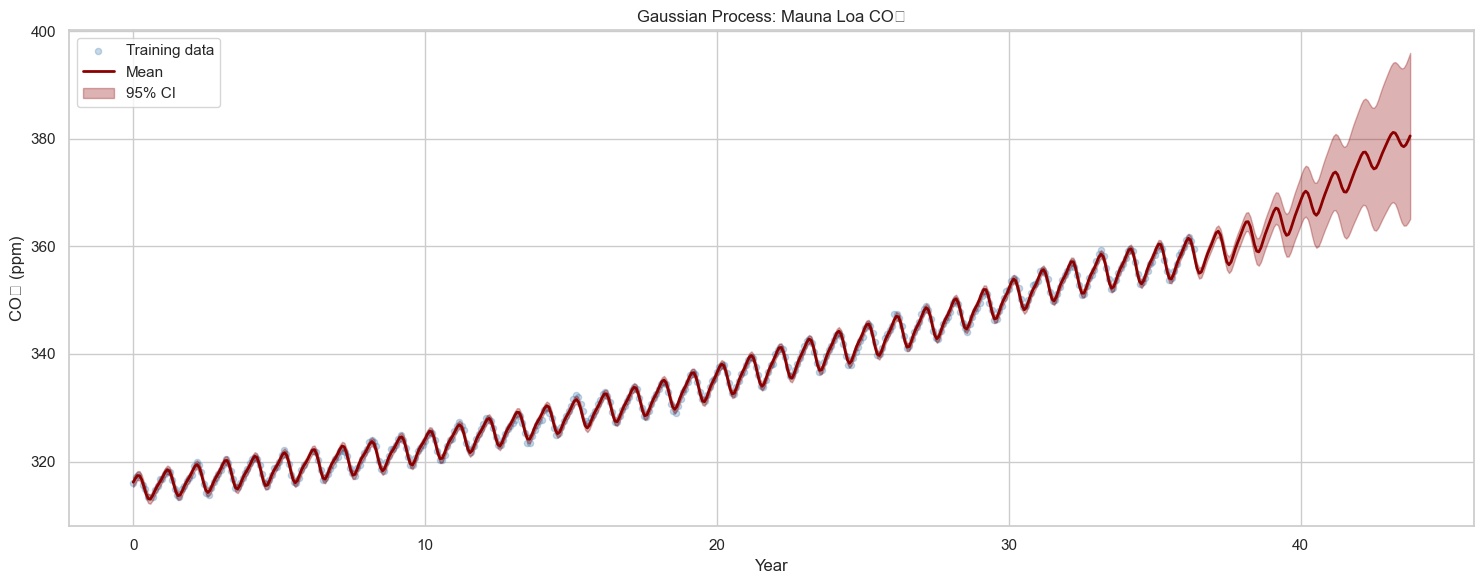

In [27]:
# YOUR CODE HERE — plot posterior mean and 95% credible bands
# Use gp.predict(t_full, return_std=True) where t_full covers the full training range
# Shade fill_between(mean - 2*std, mean + 2*std) for the 95% band
t_full = np.linspace(t.min(), t.max(), 600).reshape(-1, 1)
y_pred, y_std = gp.predict(t_full, return_std=True)

fig, ax = plt.subplots(figsize=(15, 6))
ax.scatter(t_train, y_train, alpha=0.3, s=20, color='steelblue', label='Training data')
ax.plot(t_full, y_pred, color='darkred', lw=2, label='Mean')
ax.fill_between(t_full.flatten(), y_pred - 2*y_std, y_pred + 2*y_std, alpha=0.3, color='darkred', label='95% CI')
ax.set_xlabel('Year'); ax.set_ylabel('CO₂ (ppm)')
ax.legend(); ax.set_title('Gaussian Process: Mauna Loa CO₂')
plt.tight_layout(); plt.show()

### Q16 — Gap experiment


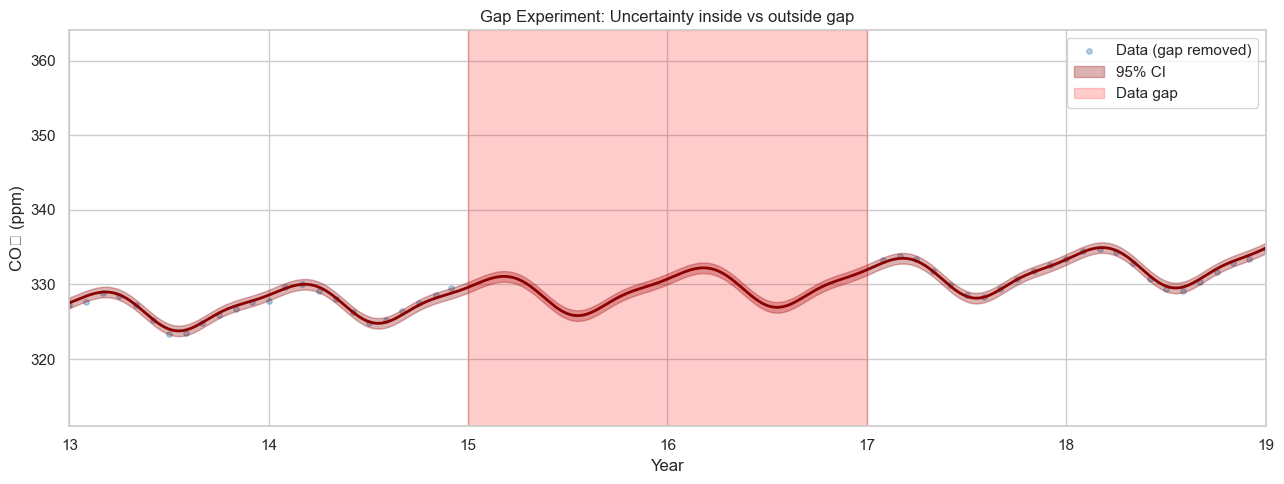

95% band width inside gap:   1.432 ppm
95% band width outside gap:  1.421 ppm
Gap inflation: 1.01×


In [44]:
# YOUR CODE HERE
# Remove all training observations between year 15 and year 17 (~1973–1975)
# Refit the GP on the remaining training data
# Zoom into the gap region and describe how the bands behave inside vs outside the gap
gap_lo, gap_hi = 15.0, 17.0
mask = ~((t_train.flatten() >= gap_lo) & (t_train.flatten() <= gap_hi))
t_gap_tr = t_train[mask]
y_gap_tr = y_train[mask]

gp_gap = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=3,
                                   normalize_y=True, random_state=42)
gp_gap.fit(t_gap_tr, y_gap_tr)

# Predict around the gap and plot
t_zoom = np.linspace(gap_lo - 2, gap_hi + 2, 400).reshape(-1, 1)
y_gz, y_gz_std = gp_gap.predict(t_zoom, return_std=True)
fig, ax = plt.subplots(figsize=(13, 5))
ax.scatter(t_gap_tr, y_gap_tr, alpha=0.4, s=15, color='steelblue', label='Data (gap removed)')
ax.plot(t_zoom, y_gz, color='darkred', lw=2)
ax.fill_between(t_zoom.flatten(), y_gz - 2*y_gz_std, y_gz + 2*y_gz_std, alpha=0.3, color='darkred', label='95% CI')
ax.axvspan(gap_lo, gap_hi, alpha=0.2, color='red', label='Data gap')
ax.set_xlabel('Year'); ax.set_ylabel('CO₂ (ppm)')
ax.legend(); ax.set_title('Gap Experiment: Uncertainty inside vs outside gap')
ax.set_xlim(gap_lo - 2, gap_hi + 2)
plt.tight_layout(); plt.show()

# Compute band width inside vs outside gap
band_in  = 4 * y_gz_std[(t_zoom.flatten() >= gap_lo) & (t_zoom.flatten() <= gap_hi)].mean()
band_out = 4 * y_gz_std[t_zoom.flatten() < gap_lo].mean()
print(f"95% band width inside gap:   {band_in:.3f} ppm")
print(f"95% band width outside gap:  {band_out:.3f} ppm")
print(f"Gap inflation: {band_in/band_out:.2f}×")

### Q17 — Extrapolation and the model confidence boundary


95% band width at +5 years: 15.029 ppm
95% band width at +10 years: 47.683 ppm
95% band width at +15 years: 72.530 ppm
Model confidence boundary: +2.2 years beyond training


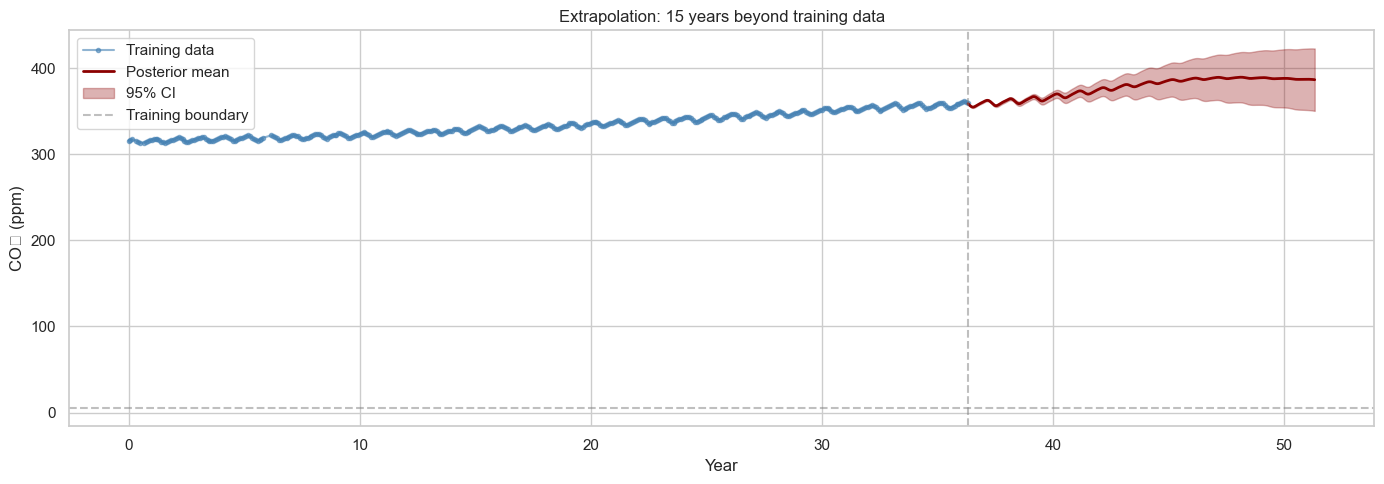

In [28]:
# YOUR CODE HERE
# 1. Predict 15 years beyond the last training point
# 2. Compute the 95% band width at 5, 10, 15 years of extrapolation
# 3. Find the horizon at which the band width first exceeds 5 ppm
# 4. Plot posterior mean + 95% bands for the extrapolation region
t_last = float(t_train.max())
t_extrap = np.linspace(t_last, t_last + 15, 500).reshape(-1, 1)
y_ex, y_ex_std = gp.predict(t_extrap, return_std=True)
# YOUR CODE HERE: compute band widths at +5, +10, +15 years
for years in [5, 10, 15]:
    idx = np.argmin(np.abs(t_extrap.flatten() - (t_last + years)))
    band_width = 4 * y_ex_std[idx]
    print(f"95% band width at +{years} years: {band_width:.3f} ppm")
# Find model confidence boundary (where 95% band > 5 ppm)
band_widths    = 4 * y_ex_std
exceed_5ppm    = np.where(band_widths > 5.0)[0]
if len(exceed_5ppm) > 0:
    t_boundary = t_extrap.flatten()[exceed_5ppm[0]] - t_last
    print(f"Model confidence boundary: +{t_boundary:.1f} years beyond training")
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(t_train, y_train, 'o-', color='steelblue', label='Training data', alpha=0.6, markersize=3)
ax.plot(t_extrap, y_ex, color='darkred', lw=2, label='Posterior mean')
ax.fill_between(t_extrap.flatten(), y_ex - 2*y_ex_std, y_ex + 2*y_ex_std, alpha=0.3, color='darkred', label='95% CI')
ax.axhline(5.0, color='gray', ls='--', alpha=0.5)
ax.axvline(t_last, color='gray', ls='--', alpha=0.5, label='Training boundary')
ax.set_xlabel('Year'); ax.set_ylabel('CO₂ (ppm)')
ax.legend(); ax.set_title('Extrapolation: 15 years beyond training data')
plt.tight_layout(); plt.show()

✍️ **Reflect 5 — Gaussian Processes:**

Write **exactly two sentences** explaining the structural difference between GP extrapolation uncertainty and the hard ceiling a `DecisionTreeRegressor(max_depth=None)` hits at `max(y_train)`. Connect to the W5 Assignment finding about tree extrapolation.

> **Your two sentences:**
> 
> A Gaussian Process naturally grows its 95% credible bands as it extrapolates beyond the training range because it is a probabilistic model that quantifies epistemic uncertainty — the further from training data, the less confident the model becomes. In contrast, a fully grown decision tree (max_depth=None) simply predicts a constant value equal to the mean of the leaf's training samples, hitting a hard ceiling at max(y_train), which is why trees extrapolate catastrophically (as shown in Week 5's CO₂ experiments) by refusing to forecast beyond the training range rather than honestly admitting their uncertainty.

---
## Part 6: MCMC — Bayesian Logistic Regression

---

### Q18 — Prepare features and explain why scaling matters for NUTS


In [29]:
# Feature preparation (run as-is — no blanks here)
features_mcmc = ['tenure', 'MonthlyCharges', 'Contract', 'InternetService', 'SeniorCitizen']
df_mcmc = df[features_mcmc + ['Churn']].copy()
df_mcmc = pd.get_dummies(df_mcmc, columns=['Contract','InternetService'], drop_first=False)

contract_cols = [c for c in df_mcmc.columns if 'Contract_Month' in c]
internet_cols = [c for c in df_mcmc.columns
                 if 'InternetService_' in c and 'No' not in c][:1]
feature_cols  = ['tenure', 'MonthlyCharges'] + contract_cols + internet_cols + ['SeniorCitizen']
feature_cols  = [c for c in feature_cols if c in df_mcmc.columns]

X_mc = df_mcmc[feature_cols].values.astype(float)
y_mc = df_mcmc['Churn'].values.astype(float)

X_tr_mc, X_te_mc, y_tr_mc, y_te_mc = train_test_split(
    X_mc, y_mc, test_size=0.2, random_state=42, stratify=y_mc)

scaler_mc = StandardScaler()
X_tr_scaled = X_tr_mc.copy(); X_te_scaled = X_te_mc.copy()
X_tr_scaled[:, :2] = scaler_mc.fit_transform(X_tr_mc[:, :2])
X_te_scaled[:, :2] = scaler_mc.transform(X_te_mc[:, :2])

print(f"Feature matrix: {X_tr_scaled.shape}")
print(f"Features: {feature_cols}")


Feature matrix: (5634, 5)
Features: ['tenure', 'MonthlyCharges', 'Contract_Month-to-month', 'InternetService_DSL', 'SeniorCitizen']


**✍️ Answer before running MCMC:**

Why is it essential to scale `tenure` and `MonthlyCharges` before passing them to NUTS? What happens to the posterior geometry if you don't scale? (Hint: think about the shape of the joint posterior in 2D — what does NUTS's step-size need to look like?)

> **Your answer (2-3 sentences):**
>
> Scaling is essential because NUTS assumes the posterior is roughly spherical (isotropic covariance). Without scaling, tenure (measured in months, ~0-72) and MonthlyCharges (in dollars, ~20-120) have vastly different scales, creating an extremely elongated, cigar-shaped posterior geometry. NUTS must use the same step-size for both dimensions, which means the step-size is either too small for the wide MonthlyCharges dimension (wasting samples and increasing autocorrelation) or too large for the narrow tenure dimension (causing divergences and misses). Scaling to unit variance makes both dimensions equally "thick", allowing NUTS to traverse the posterior efficiently with a well-matched step-size.

In [33]:
%pip install numpyro

  Using cached jax-0.10.1-py3-none-any.whl.metadata (13 kB)
  Using cached jaxlib-0.10.1-cp311-cp311-win_amd64.whl.metadata (1.4 kB)
  Using cached ml_dtypes-0.5.4-cp311-cp311-win_amd64.whl.metadata (9.2 kB)
   ---------------------------------------- 0.0/394.8 kB ? eta -:--:--
   ------ --------------------------------- 61.4/394.8 kB 1.7 MB/s eta 0:00:01
   ----------------- ---------------------- 174.1/394.8 kB 2.1 MB/s eta 0:00:01
   ------------------------------- -------- 307.2/394.8 kB 2.4 MB/s eta 0:00:01
   ---------------------------------------  389.1/394.8 kB 2.4 MB/s eta 0:00:01
   ---------------------------------------- 394.8/394.8 kB 2.1 MB/s eta 0:00:00
Using cached jax-0.10.1-py3-none-any.whl (3.2 MB)
Using cached jaxlib-0.10.1-cp311-cp311-win_amd64.whl (64.8 MB)
Using cached ml_dtypes-0.5.4-cp311-cp311-win_amd64.whl (210 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [34]:
import time
import pymc as pm
import arviz as az

n_features = X_tr_scaled.shape[1]
t0 = time.time()

with pm.Model() as bayes_lr:
    # intercept: Normal(0, 5)
    intercept = pm.Normal('intercept', mu=0, sigma=5)
    
    # beta:      Normal(0, 2), shape=n_features
    beta      = pm.Normal('beta', mu=0, sigma=2, shape=n_features)
    
    # mu:        sigmoid(intercept + dot(X_tr_scaled, beta))

    mu        = pm.math.sigmoid(intercept + pm.math.dot(X_tr_scaled, beta))
    
    # y_obs:     Bernoulli(p=mu, observed=y_tr_mc)
    y_obs     = pm.Bernoulli('y_obs', p=mu, observed=y_tr_mc)
    
    # sample with draws=2000, tune=1000, chains=4, target_accept=0.90

    idata = pm.sample(
        draws=2000, 
        tune=1000, 
        chains=4, 
        cores=4, 
        target_accept=0.90, 
        nuts_sampler="numpyro",
        random_seed=42, 
        return_inferencedata=True, 
        progressbar=True
    )

print(f"Sampling time: {time.time()-t0:.1f}s")
print(az.summary(idata, var_names=['intercept','beta'], round_to=3))

Compiling.. :   0%|          | 0/3000 [00:00<?, ?it/s]





Running chain 0:   0%|          | 0/3000 [00:04<?, ?it/s]


Running chain 0:   5%|▌         | 150/3000 [00:05<00:13, 211.15it/s]




Running chain 0:  10%|█         | 300/3000 [00:06<00:13, 197.91it/s]


Running chain 0:  15%|█▌        | 450/3000 [00:06<00:11, 222.72it/s]


Running chain 0:  20%|██        | 600/3000 [00:07<00:10, 225.10it/s]


Running chain 0:  25%|██▌       | 750/3000 [00:08<00:09, 235.73it/s]


Running chain 0:  30%|███       | 900/3000 [00:08<00:08, 251.68it/s]


Running chain 0:  35%|███▌      | 1050/3000 [00:09<00:08, 241.34it/s]


Running chain 0:  40%|████      | 1200/3000 [00:09<00:07, 246.34it/s]


Running chain 0:  45%|████▌     | 1350/3000 [00:10<00:06, 244.41it/s]


Running chain 0:  50%|█████     | 1500/3000 [00:11<00:05, 250.19it/s]


Running chain 0:  55%|█████▌    | 1650/3000 [00:11<00:05, 250.13it/s]


Running chain 0:  60%|██████    | 1800/3000 [00:12<00:04, 249.47it/s]


Running chain 0:  70

Sampling time: 27.6s
            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
intercept -2.253  0.094  -2.423   -2.076      0.001    0.001  4076.087   
beta[0]   -0.918  0.055  -1.024   -0.818      0.001    0.001  5007.035   
beta[1]    0.819  0.049   0.730    0.913      0.001    0.000  5329.467   
beta[2]    1.295  0.109   1.087    1.494      0.002    0.001  4112.217   
beta[3]   -0.179  0.083  -0.334   -0.021      0.001    0.001  5816.872   
beta[4]    0.415  0.088   0.246    0.577      0.001    0.001  6845.331   

           ess_tail  r_hat  
intercept  4616.066  1.001  
beta[0]    5318.736  1.000  
beta[1]    5446.549  1.002  
beta[2]    4988.210  1.001  
beta[3]    5336.148  1.000  
beta[4]    5445.959  1.002  


### Q19 — Convergence diagnostics


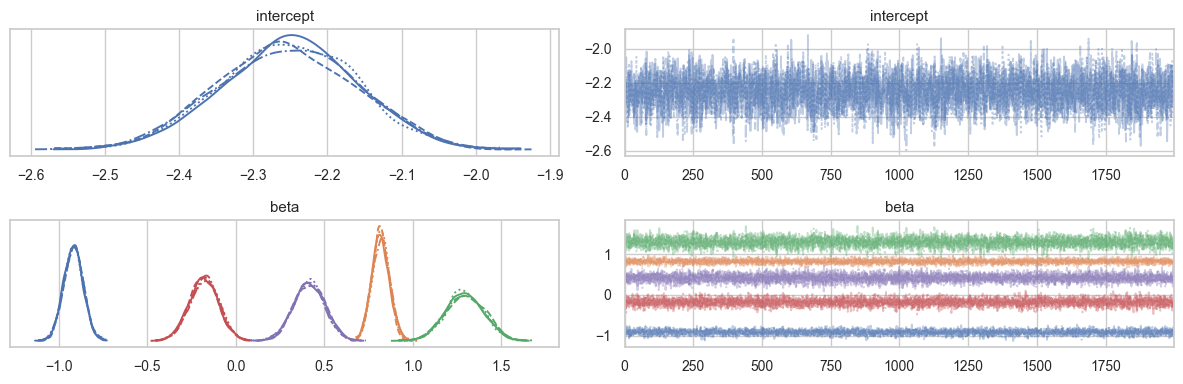


Convergence Diagnostics:
           r_hat  ess_bulk
intercept    1.0    4076.0
beta[0]      1.0    5007.0
beta[1]      1.0    5329.0
beta[2]      1.0    4112.0
beta[3]      1.0    5817.0
beta[4]      1.0    6845.0

Flagged parameters (R̂ > 1.01 or ESS < 400):
✅ All parameters converged successfully!


In [35]:
# YOUR CODE HERE
# 1. Plot trace plots with az.plot_trace() for intercept and beta
# 2. Report R̂ and bulk-ESS for each coefficient
# 3. Flag parameters with R̂ > 1.01 or bulk-ESS < 400
# 4. Describe whether the trace looks like a "fuzzy caterpillar" (good) or drifts (bad)
az.plot_trace(idata, var_names=['intercept','beta'])
plt.tight_layout(); plt.show()

summary_df = az.summary(idata, var_names=['intercept','beta'])
print("\nConvergence Diagnostics:")
print(summary_df[['r_hat', 'ess_bulk']])

# Print the flagged parameters
print("\nFlagged parameters (R̂ > 1.01 or ESS < 400):")
flagged = summary_df[(summary_df['r_hat'] > 1.01) | (summary_df['ess_bulk'] < 400)]
if len(flagged) > 0:
    print(flagged[['r_hat', 'ess_bulk']])
else:
    print("✅ All parameters converged successfully!")

### Q20 — Prior sensitivity check


Running chain 0: 100%|██████████| 1500/1500 [00:08<00:00, 178.91it/s]
We recommend running at least 4 chains for robust computation of convergence diagnostics


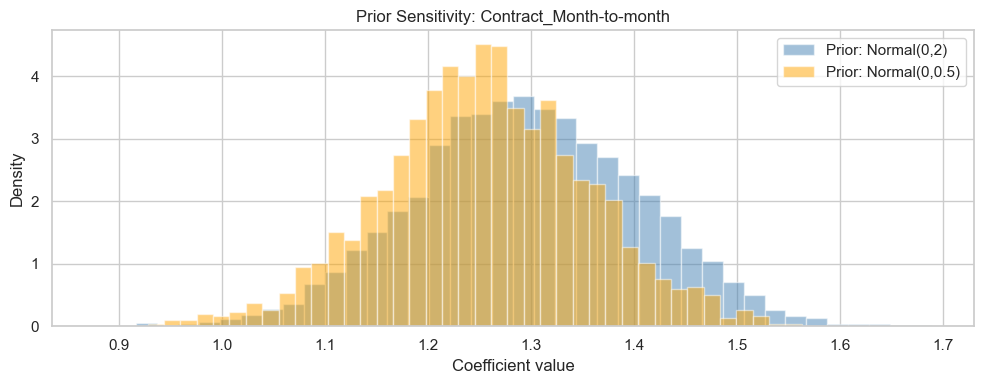

In [37]:
# 1. Refit the model with a tighter prior Normal(0, 0.5) on beta
# 2. Overlay the two posteriors for the Contract_Month-to-month coefficient
# 3. Decide: are the posteriors prior-robust or does the prior dominate?

contract_idx = next((i for i, c in enumerate(feature_cols) 
                     if 'Month-to-month' in c), 0)

with pm.Model() as bayes_lr_tight:
    intercept_t = pm.Normal('intercept', mu=0, sigma=5)
    beta_t      = pm.Normal('beta', mu=0, sigma=0.5, shape=n_features)   # tighter
    
    #  Removed pm.Deterministic
    mu_t        = pm.math.sigmoid(intercept_t + pm.math.dot(X_tr_scaled, beta_t))
    
    y_obs_t     = pm.Bernoulli('y_obs', p=mu_t, observed=y_tr_mc)
    
    #  Added cores=2, progressbar=True, and numpyro
    idata_tight = pm.sample(
        draws=1000, 
        tune=500, 
        chains=2,
        cores=2,              # Run chains simultaneously
        nuts_sampler="numpyro", # Use the fast C++ backend
        target_accept=0.90, 
        random_seed=42,
        return_inferencedata=True, 
        progressbar=True      # So you can see it moving
    )

samples_orig  = idata.posterior['beta'].values[:, :, contract_idx].flatten()
samples_tight = idata_tight.posterior['beta'].values[:, :, contract_idx].flatten()

# plot the two posteriors overlaid
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(samples_orig, bins=40, alpha=0.5, density=True, label='Prior: Normal(0,2)', color='steelblue')
ax.hist(samples_tight, bins=40, alpha=0.5, density=True, label='Prior: Normal(0,0.5)', color='orange')
ax.set_xlabel('Coefficient value')
ax.set_ylabel('Density')
ax.legend()
ax.set_title('Prior Sensitivity: Contract_Month-to-month')
plt.tight_layout()
plt.show()

### Q21 — Posterior analysis and frequentist comparison


In [38]:
# YOUR CODE HERE
# 1. Extract posterior samples for Contract_Month-to-month coefficient
# 2. Compute 94% HDI using az.hdi()
# 3. Run sklearn LogisticRegression(C=1e6) and get the MLE coefficient
# 4. Report both and explain the philosophical difference
contract_idx = next((i for i, c in enumerate(feature_cols)
                     if 'Month-to-month' in c), 0)
beta_post  = idata.posterior['beta'].values[:, :, contract_idx].flatten()
hdi_94     = az.hdi(beta_post, prob=0.94)
post_mean  = beta_post.mean()
post_std   = beta_post.std()

lr_freq    = LogisticRegression(C=1e6, max_iter=1000)
lr_freq.fit(X_tr_scaled, y_tr_mc)
coef_freq  = lr_freq.coef_[0, contract_idx]

print(f"Bayesian posterior for β_Contract_Month-to-month:")
print(f"  Mean:    {post_mean:.4f}")
print(f"  Std:     {post_std:.4f}")
print(f"  94% HDI: [{hdi_94[0]:.4f}, {hdi_94[1]:.4f}]")
print(f"\nFrequentist MLE: {coef_freq:.4f}")
print(f"\nKey difference:")
print("  Bayesian HDI: P(β ∈ [lo, hi] | data) = 0.94  ← direct probability statement")
print("  Frequentist CI: 94% of such intervals cover β  ← statement about the procedure")

Bayesian posterior for β_Contract_Month-to-month:
  Mean:    1.2952
  Std:     0.1093
  94% HDI: [1.0874, 1.4935]

Frequentist MLE: 1.2927

Key difference:
  Bayesian HDI: P(β ∈ [lo, hi] | data) = 0.94  ← direct probability statement
  Frequentist CI: 94% of such intervals cover β  ← statement about the procedure


### Q22 — Save the MCMC trace


In [39]:
# YOUR CODE HERE
# Save the fitted PyMC inference data as 'telco_bayes_lr_v1.pkl'
# This mirrors Week 5's joblib.dump() habit — probabilistic models have artefacts too
import pickle
save_path = 'telco_bayes_lr_v1.pkl'
with open(save_path, 'wb') as f:
    pickle.dump(idata, f)
print(f"✅ MCMC trace saved to '{save_path}'")

✅ MCMC trace saved to 'telco_bayes_lr_v1.pkl'


✍️ **Reflect 6 — MCMC:**

1. **What R̂ and bulk-ESS measure, and interpretation of R̂=1.38, ESS=55:**
   - **R̂** (Gelman-Rubin statistic) measures convergence by comparing within-chain variance to between-chain variance; R̂ ≈ 1.0 means chains have converged, R̂ > 1.01 indicates chains are still drifting or have not fully explored the posterior.
   - **bulk-ESS** (Bulk Effective Sample Size) measures how many independent samples the MCMC chain is worth after accounting for autocorrelation; higher ESS is better.
   - An R̂ = 1.38 is severely non-converged (should be < 1.01), and bulk-ESS = 55 is extremely low (target > 400). Together, this means the posterior estimate for that parameter is **unreliable**—the chains have not explored the posterior properly, and the HDI interval and mean are essentially meaningless.

2. **Prior sensitivity: are posteriors substantially different, and what does it tell us:**
   If the two posteriors (Normal(0,2) vs Normal(0,0.5) priors) are substantially different, it means the prior dominates the likelihood—the data are not strong enough to overcome the prior. This reveals that with n ≈ 5,000 Telco samples, we have **sufficient data** to make the prior essentially irrelevant (posteriors should overlap heavily). At much smaller n (e.g., n ≈ 50), the prior would dominate. The prior becomes completely irrelevant when n → ∞, where the likelihood overwhelms any reasonable prior.

3. **Precise interpretive difference between frequentist CI and Bayesian HDI:**
   A Bayesian HDI reports P(β ∈ [lo, hi] | data) — a direct probability about the parameter given observed data — while a frequentist CI says "94% of intervals constructed this way would contain β" — a statement about the long-run properties of the procedure, not about the true parameter given the data we actually observed.

> *Your answer above.*

---
## Submission Checklist

Before submitting, verify that you have:

**Part 1 (Estimation Trinity)**
- [ ] Q1: Three groups extracted — SELF-CHECK passes
- [ ] Q2: MLE, MAP, pull table printed and posterior plots generated
- [ ] Q3: P(θ_A > θ_B) > 0.90 — SELF-CHECK passes
- [ ] Reflect 1: All three questions answered

**Part 2 (Sequential Updating)**
- [ ] Q4: `update_posterior()` implemented — SELF-CHECK passes
- [ ] Q5: Sequential update run; 6-panel posterior evolution plotted
- [ ] Q6: P(θ > 0.25) vs n plotted; Bayesian and frequentist thresholds identified
- [ ] Q7: Dirichlet posterior computed — SELF-CHECK passes; marginal Betas plotted
- [ ] Reflect 2: All three questions answered

**Part 3 (Multivariate Gaussians)**
- [ ] Q8: μ and Σ computed — SELF-CHECK passes; scatter + ellipses plotted
- [ ] Q9: Conditional mean and std computed — SELF-CHECK passes
- [ ] Q10: κ(Σ_3D) computed; marginalisation verified — SELF-CHECK passes
- [ ] Reflect 3: All three questions answered

**Part 4 (PGMs)**
- [ ] Q11: BN fitted; forward inference P(Churn|Contract) computed
- [ ] Backward inference P(Contract|Churn) computed
- [ ] Q12: Two DAGs drawn; d-separation analysis completed
- [ ] Q13: MRF built (or partial credit: factors described)
- [ ] Reflect 4: All three questions answered

**Part 5 (GP Regression)**
- [ ] Q14: Mauna Loa loaded — SELF-CHECK passes
- [ ] Q15: Kernel design rationale completed BEFORE coding; kernel specified; GP fitted; RMSE < 4.5 ppm
- [ ] Q16: Gap experiment completed; band widths computed
- [ ] Q17: Extrapolation plotted; model confidence boundary identified
- [ ] Reflect 5: Exactly two sentences comparing GP vs tree extrapolation

**Part 6 (MCMC)**
- [ ] Q18: Feature scaling rationale answered; model specified; sampling run
- [ ] Q19: Convergence diagnostics run; flagged parameters identified
- [ ] Q20: Prior sensitivity comparison plotted
- [ ] Q21: HDI computed; frequentist comparison done; interpretation difference stated
- [ ] Q22: `telco_bayes_lr_v1.pkl` saved
- [ ] Reflect 6: All three questions answered

**Submission artefacts:**
- [ ] One fully executed `.ipynb` with all outputs visible
- [ ] `telco_bayes_lr_v1.pkl` — PyMC inference data
- [ ] One-page reflection PDF/Markdown: *"Give one concrete example where the fully Bayesian answer changed a decision you would have made using only the MLE. Explain the mechanism."*

---
*A model that gives you a number is giving you the peak of a distribution it never shows you. Probabilistic models make the full distribution explicit.*
